# 04 — Explainability with SHAP
Why does the model flag a given customer as high-risk?

In [4]:
import pandas as pd
import joblib
import shap
import glob
from sklearn.model_selection import train_test_split

df = pd.read_csv('../data/processed/churn_processed.csv')
X = df.drop(columns=['Churn'])
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

model_path = glob.glob('../models/best_model_*.pkl')[0]
model = joblib.load(model_path)
print('Loaded:', model_path)

Loaded: ../models\best_model_hgb.pkl


## Global feature importance — SHAP summary plot

Background dataset has 5634 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=5634 when initializing the masker.
PermutationExplainer explainer: 201it [01:31,  2.20it/s]                         
C:\Users\saart\AppData\Local\Temp\ipykernel_14776\3410452615.py:11: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_sample, show=False)


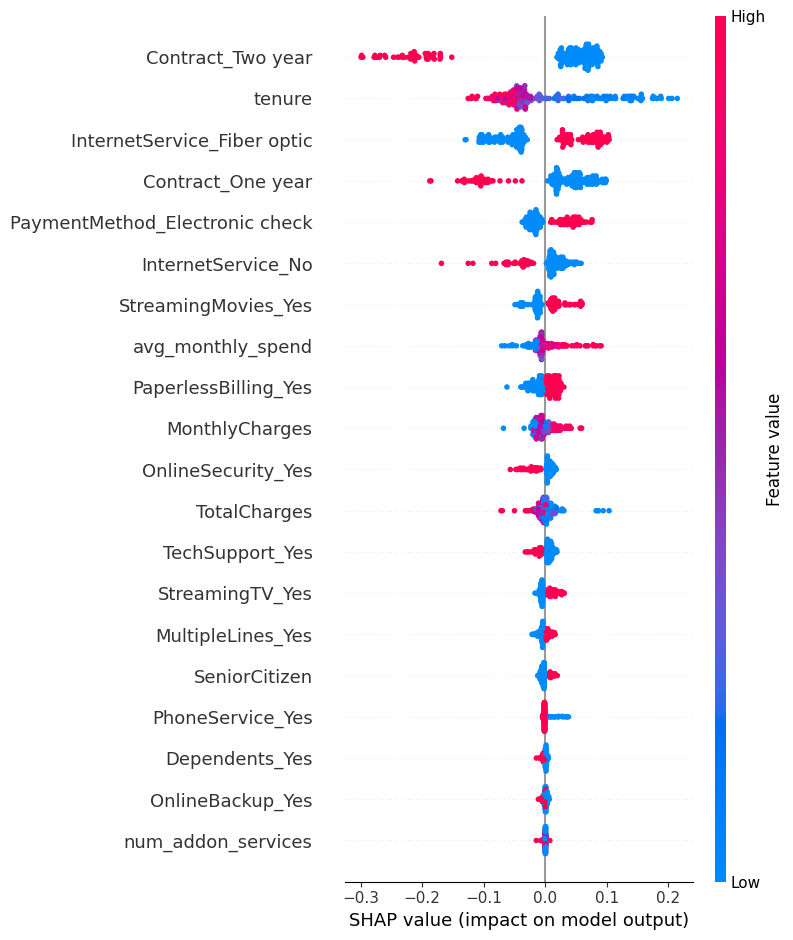

In [7]:
import matplotlib.pyplot as plt

# Convert everything to plain numbers (fixes a True/False vs number mismatch)
X_train_shap = X_train.astype(float)
X_test_sample = X_test.sample(200, random_state=42).astype(float)

predict_fn = lambda x: model.predict_proba(x)[:, 1]
explainer = shap.Explainer(predict_fn, X_train_shap, algorithm="permutation")
shap_values = explainer(X_test_sample)

shap.summary_plot(shap_values, X_test_sample, show=False)
plt.savefig('../reports/figures/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

## Explaining individual predictions
Pick a couple of high-risk customers and show exactly which features pushed their churn probability up.

Customer index 133 — predicted churn probability: 0.90


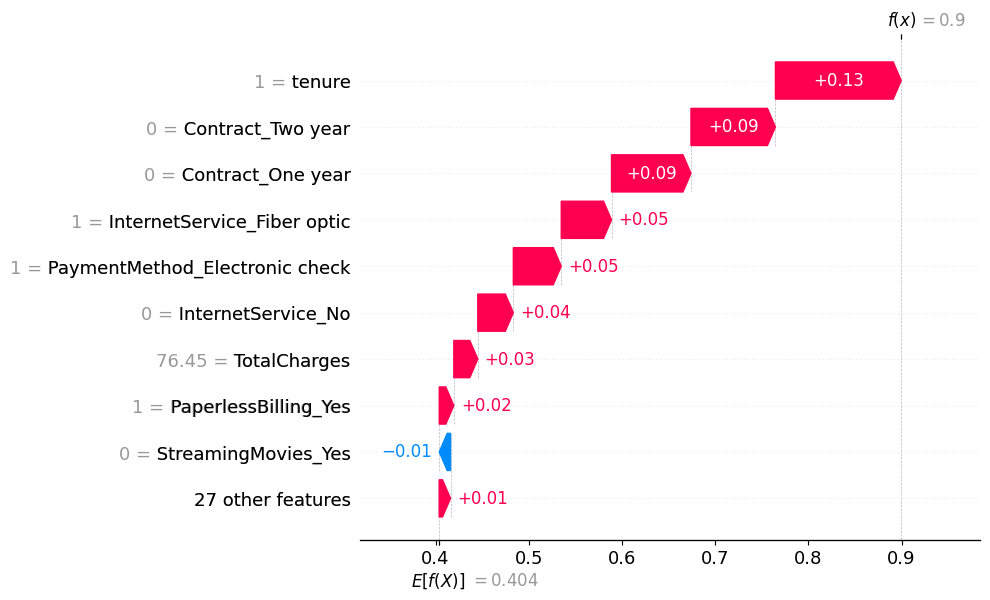

Customer index 9 — predicted churn probability: 0.90


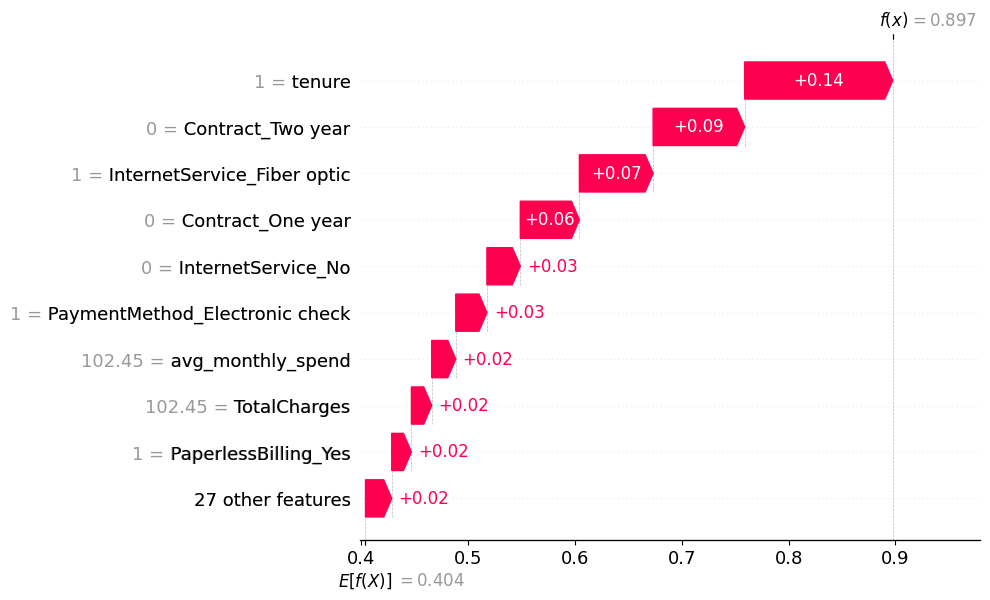

Customer index 118 — predicted churn probability: 0.89


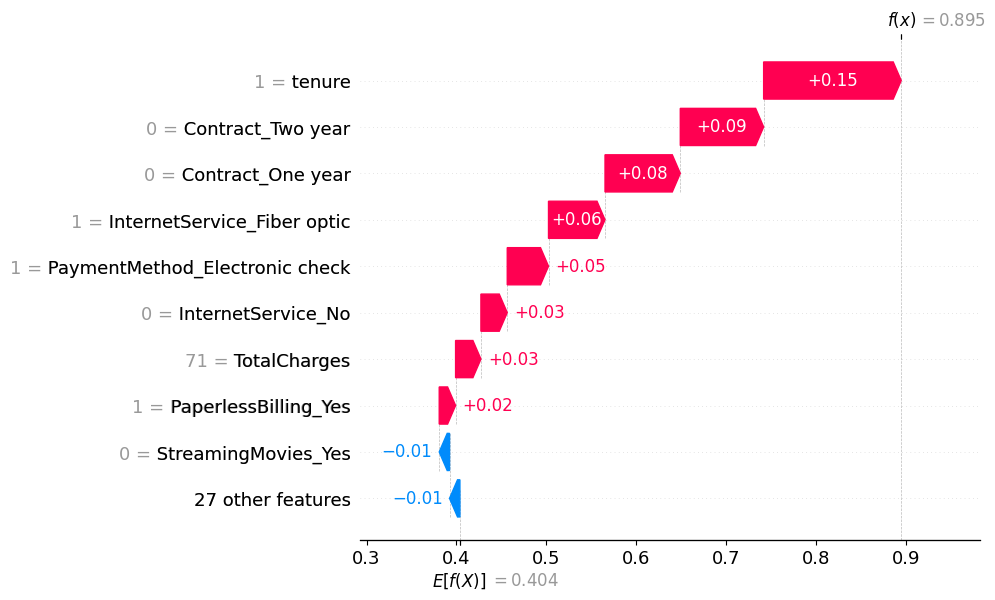

In [10]:
probs_sample = model.predict_proba(X_test_sample)[:, 1]
top_risk_idx = probs_sample.argsort()[::-1][:3]

for i in top_risk_idx:
    print(f'Customer index {i} — predicted churn probability: {probs_sample[i]:.2f}')
    shap.plots.waterfall(shap_values[i], show=True)

## Takeaways for the business

- **Contract type is the single biggest churn driver.** Customers on two-year contracts churn at 2.8%, versus 42.7% for month-to-month customers — a >15x difference. The SHAP plot confirms this isn't just a correlation in the raw data; the model relies on it heavily too.
- **Tenure compounds the risk.** New customers (low tenure) on month-to-month contracts are the highest-risk segment by far — this group churns at 56.1%, nearly 3x the overall rate.
- **Fiber optic internet customers churn more** (41.9% vs 19.0% for DSL), despite presumably being a premium product — likely pointing to a pricing or service-quality issue worth investigating, not just a targeting problem.
- **A new finding from SHAP that EDA missed:** customers paying via electronic check show elevated churn risk independent of contract or tenure — possibly a proxy for a less "locked-in" payment relationship (e.g. no autopay), worth a follow-up look.

**Recommendation:** Prioritize retention outreach for month-to-month, low-tenure, fiber-optic customers — a relatively small segment responsible for a disproportionate share of cancellations. Consider testing incentives to move month-to-month customers onto annual contracts, since contract length is the strongest lever the data points to.